# DREAMS Snapshot Hosting Capacity




# Load Feeder

In [1]:
import dreams

from pathlib import Path
import os

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')


initial plot and stat display for pre/post visuals and background

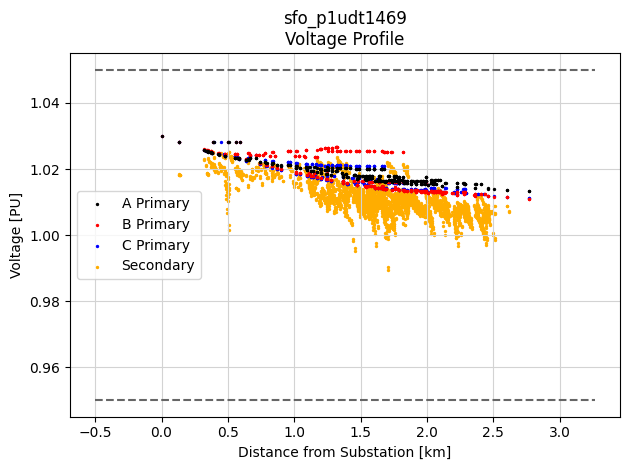

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'sfo_p1udt1469\nVoltage Profile'}, xlabel='Distance from Substation [km]', ylabel='Voltage [PU]'>)

In [4]:

feeder.plot()

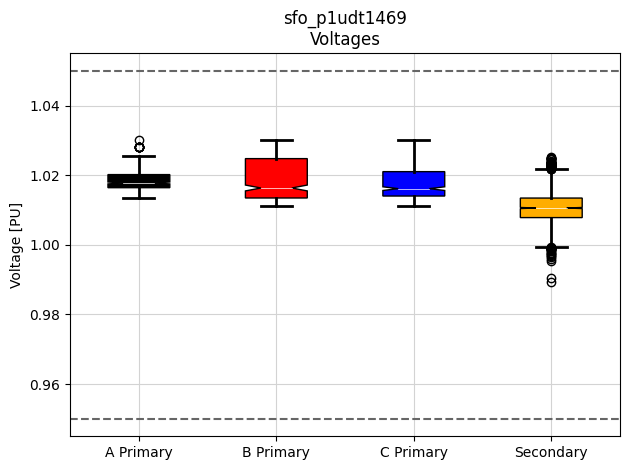

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'sfo_p1udt1469\nVoltages'}, ylabel='Voltage [PU]'>)

In [5]:
feeder.plot(kind='box')

In [6]:
feeder.stats['init_kw']

6144.109120674652

In [7]:
feeder.stats['n_cust']

2120

# Create Hosting Capacity Scenario 

simple distributed load situation

lvl 2 ev charging, 1% increase of coincident lvl 2 charging per step



In [8]:
scenario = dreams.hc.Scenario(
    name='Snapshot Distributed Load',
    feeder=feeder,
    n_simulations=25,  # This is how many different random sets of allocations to run
    n_steps=5,  # this is how many steps from 0-full allocation each simulation takes
    #minimize_duplicates=False,  # Defaults to True, attempts to allocate elements to all available locations before stacking locations
)

## creation of alloctaion class and element

In [9]:
# allocation class acts as container for  allocation elements
ev_alloc_2 = dreams.hc.Allocation(feeder, name='LVL_2_EV') 

# calculate number of level 2 chargers to add per scenario step
n_lvl_2 = int(feeder.stats['n_cust'] * .01)

# create load allocation element
lvl2_ev = dreams.hc.LoadAllocationElement(
    'LVL_2_EV',
    element_prepend='EV_LVL_2_',
    element_kw=15,
    element_kvar=0,
    n_elements=n_lvl_2
)

# add load elemnt to allocation
ev_alloc_2.add_allocation_element(lvl2_ev)

# display contents of ev_alloc_2 rules
ev_alloc_2.rules

{'element': {'LVL_2_EV': Load Element Name: LVL_2_EV // 0 elements allocated // Total: 0 kw 0 kvar},
 'location': {},
 'capacity': {},
 'size': {},
 'control': {},
 'shape': {}}

## definition of allocation location rule

In [10]:

ev_alloc_2.add_location_rule(
    name='Secondary of C Phase Transformers',
    feeder_element_class='transformers',
    element_attribute='bus1_phase',
    comparison_operation='==',
    comparison_value='C',
    bus1_attribute='bus2')

scenario.add_allocation(ev_alloc_2)

A note about the available busses on the C phase

In [11]:
(feeder.transformers['bus1_phase'] == 'C').sum()

62

# writing of scenario steps and running of simulation

In [12]:
scenario.write_steps()  

In [13]:
scenario.run()

Started Snapshot Simulation
Completed seed: 0
Completed seed: 9225
Completed seed: 6921
Completed seed: 3468
Completed seed: 6036
Completed seed: 4373
Completed seed: 537
Completed seed: 9893
Completed seed: 2599
Completed seed: 2732
Completed seed: 2222
Completed seed: 3264
Completed seed: 705
Completed seed: 7877
Completed seed: 6216
Completed seed: 5072
Completed seed: 2897
Completed seed: 7891
Completed seed: 7768
Completed seed: 6744
Completed seed: 5874
Completed seed: 2163
Completed seed: 4851
Completed seed: 9845
Completed seed: 4859
Finished all Seeds


# Result plots

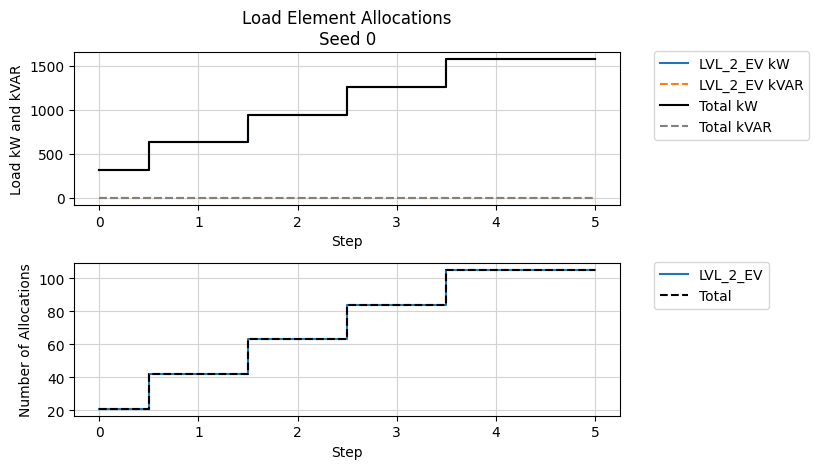

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Load Element Allocations\nSeed 0'}, xlabel='Step', ylabel='Load kW and kVAR'>,
  <Axes: xlabel='Step', ylabel='Number of Allocations'>])

In [14]:
scenario.seed_results[0].plot(kind='load_allocation')


Maybe mention different seeds?

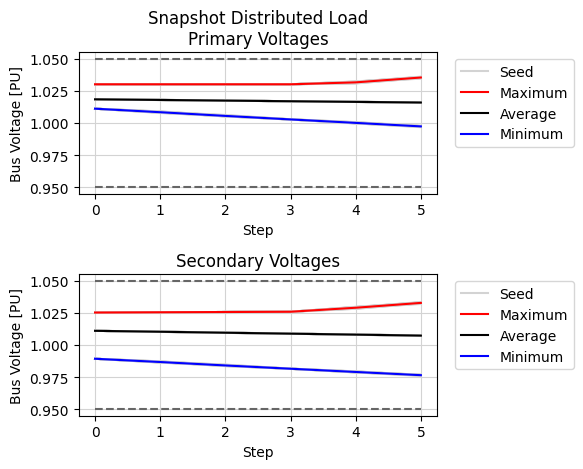

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Snapshot Distributed Load\nPrimary Voltages'}, xlabel='Step', ylabel='Bus Voltage [PU]'>,
  <Axes: title={'center': 'Secondary Voltages'}, xlabel='Step', ylabel='Bus Voltage [PU]'>])

In [15]:
scenario.results.plot()

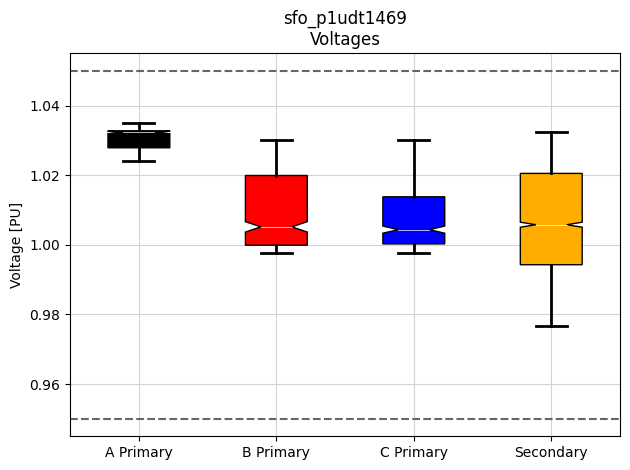

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'sfo_p1udt1469\nVoltages'}, ylabel='Voltage [PU]'>)

In [16]:
feeder.plot(kind='box')

Note that plots from feeder represent last step of last simulation run

In [17]:
feeder.plot(kind='plotly')

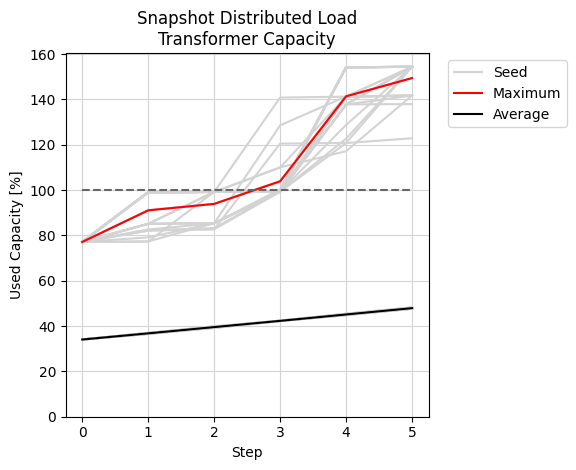

(<Figure size 640x480 with 1 Axes>,
 [<Axes: title={'center': 'Snapshot Distributed Load\nTransformer Capacity'}, xlabel='Step', ylabel='Used Capacity [%]'>])

In [18]:
scenario.results.plot(kind='transformer')

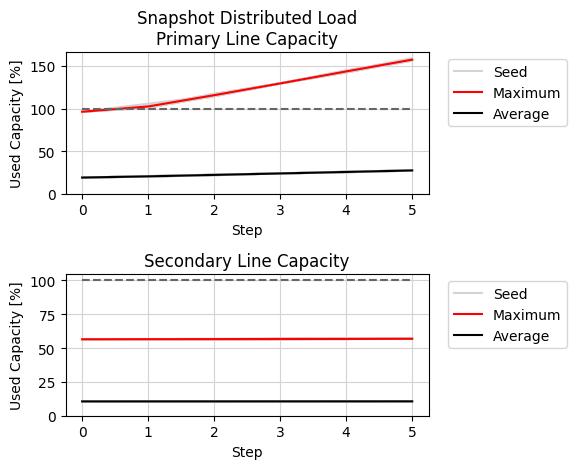

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Snapshot Distributed Load\nPrimary Line Capacity'}, xlabel='Step', ylabel='Used Capacity [%]'>,
  <Axes: title={'center': 'Secondary Line Capacity'}, xlabel='Step', ylabel='Used Capacity [%]'>])

In [19]:
scenario.results.plot(kind='line')

# go to step

In [20]:
scenario.go_to_step(step=3)

In [21]:
feeder.loads.tail(3)

,phases,kv,kw,kvar,pf,conn,bus1,model,status,short_bus1,bus1_nodes,bus1_phase,primary
name,,,,,,,,,,,,,
ev_lvl_2_61_p1udt308lv,1,0.120089,15.0,0.0,1.0,wye,p1udt308lv.1.0,1,Variable,p1udt308lv,1,A,False
ev_lvl_2_62_p1udt203lv,1,0.120089,15.0,0.0,1.0,wye,p1udt203lv.1.0,1,Variable,p1udt203lv,1,A,False
ev_lvl_2_63_p1udt6lv,1,0.120089,15.0,0.0,1.0,wye,p1udt6lv.1.0,1,Variable,p1udt6lv,1,A,False


In [22]:
feeder.id_violations()['over_capacity']

,Name,Imax,%normal,%emergency,kW,kvar,NumCustomers,TotalCustomers,NumPhases,kVBase,kind,short_name,primary
0,Line.L(R:P1UDT1469-P1UHS0_1247),414.052,127.40,69.01,7272.27,1105.110,0,2183,3,7.2,Line,L(R:P1UDT1469-P1UHS0_1247),True
1,Line.L(R:P1UDT1469-P1UDT940),401.618,123.57,66.94,7021.33,1055.570,0,2165,3,7.2,Line,L(R:P1UDT1469-P1UDT940),True
2,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557,401.618,123.57,66.94,6998.93,1028.460,0,2163,3,7.2,Line,PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557,True
3,Line.L(R:P1UDT940-P1UDT941),401.618,108.55,66.94,6998.62,1028.140,0,2163,3,7.2,Line,L(R:P1UDT940-P1UDT941),True
4,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9558,401.620,108.55,66.94,6997.65,1026.940,0,2163,3,7.2,Line,PADSWITCH(R:P1UDT940-P1UDT941)P1U_9558,True
5,Line.PADSWITCH(R:P1UDT886-P1UDT941)P1U_9555,399.964,108.10,66.66,6960.91,1022.980,0,2161,3,7.2,Line,PADSWITCH(R:P1UDT886-P1UDT941)P1U_9555,True
6,Line.L(R:P1UDT886-P1UDT941),399.964,108.10,66.66,6960.60,1022.670,0,2161,3,7.2,Line,L(R:P1UDT886-P1UDT941),True
7,Line.PADSWITCH(R:P1UDT886-P1UDT941)P1U_9556,399.965,108.10,66.66,6960.11,1022.070,0,2161,3,7.2,Line,PADSWITCH(R:P1UDT886-P1UDT941)P1U_9556,True
8,Line.PADSWITCH(R:P1UDT886-P1UDT891)P1U_9553,399.965,108.10,66.66,6947.91,1020.220,0,2155,3,7.2,Line,PADSWITCH(R:P1UDT886-P1UDT891)P1U_9553,True
9,Line.L(R:P1UDT886-P1UDT891),399.965,108.10,66.66,6947.60,1019.910,0,2155,3,7.2,Line,L(R:P1UDT886-P1UDT891),True


# GIS export
for futher qgis analysis

In [23]:
gis_dir = Path(r".\models\sfo_p1udt1469\temp_outputs")
dreams.gis.export_feeder_gpkg(feeder, output_path=gis_dir)

['models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_buses.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_capacitors.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_fuses.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_lines.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_loads.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_switches.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_transformers.gpkg',
 'models\\sfo_p1udt1469\\temp_outputs\\sfo_p1udt1469_voltage_sources.gpkg']